In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white")
import missingno as msno

#**1. Understanding the Retail Sales Dataset**:

## **1.1. Introduction**
The Retail Sales Dataset used in this analysis contains detailed records of retail sales, providing information on customer charateristics, product category, quantity purchased etc. Retail sales may be influenced by a variety of factors, and understanding such influences is essential to generate meaningful insights which can support corporations and managers in decision-making.

The reason why I chose sales domain is because it is practical and widely applicable in business analytics. The very nature of business is to make revenues and profit, and sales analysis is relevant to many industries, making the insights highly transferable.

The main analytical question for this analysis is:
**How do customer demographics, product categories, and seasonal trends influence sales?**

## Dive into the variables
- **Transaction ID**:
  - **Type**: Numerical (Integer)
  - **Description**: A unique identifier for each transaction.

- **Date**:
  - **Type**: Categorical (String)
  - **Description**: The date when the transaction occurred.

- **Customer ID**:
  - **Type**: Categorical (String)
  - **Description**: A unique identifier for each customer.

- **Gender**:
  - **Type**: Categorical (String)
  - **Description**: The gender of the customer (Male/Female).

- **Age**:
  - **Type**: Numerical (Integer)
  - **Description**: The age of the customer.

- **Product Category**:
  - **Type**: Categorical (String)
  - **Description**: The category of the purchased product (e.g., Electronics, Clothing, Beauty).

- **Quantity**:
  - **Type**: Numerical (Integer)
  - **Description**: The number of units of the product purchased.

- **Price per Unit**:
  - **Type**: Numerical (Integer)
  - **Description**: The price of one unit of the product, aiding in calculations related to total spending.

- **Total Amount**:
  - **Type**: Numerical (Integer)
  - **Description**: The total monetary value of the transaction.


##**1.2. Initial Examination of the Dataset**




In [ ]:
# Load the dataset
df = pd.read_csv('/content/retail_sales_dataset.csv')

In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print(f'Initial Shape:', df.shape)

Initial Shape: (1000, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### **Insights and Summary:**

1. **Dataset Structure:** There are 1000 observations (rows), 9 features (variables).

2. **Column Naming:**
   - Column names contain spaces and capital letters. We will convert them to snake_case for easier indexing and data manipulation.
    
3. **Incorrect Data Types:**
    - The `Date` column is of the type object. For meaningful analysis in sales trends, we will need to convert it into datetime type.
    - Columns `Customer ID`, `Gender`, and `Product Category` are of the type object, indicating they are string data type which is appropriate.
    - The `Age`, `Quantity`, `Price per Unit` and `Total Amount` are of the type integer, which is suitable to the data presented.

4. **Missing Data:** As we can see from the `df.info()`, there is no missing data. This makes it easier to work with the dataset.

#**2. Data Preprocessing**

## **2.1. Handling column names**
Based on the insights from the info() output, we will first handle the column names. For easier referencing, we'll standardize column names to **lowercase with underscores** by a function written below.

In [ ]:
def standardize_column_names(df):
    # Replace spaces with underscores and convert to lowercase
    df.columns = df.columns.str.replace(" ", "_").str.lower()

    return df

In [ ]:
df = standardize_column_names(df)

In [ ]:
df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


The column names have been standardized to snake_case and we are ready to move to the next part.

## **2.2. Handling Data Mis-types**
In this step, `date` type will be converted to datetime.

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
print(df['date'].dtype)

datetime64[ns]


## **2.3. Unique values**

In order to check if there is any inconsistency in the values, we will use the method .nunique().

In [ ]:
df.nunique()

,0
transaction_id,1000
date,345
customer_id,1000
gender,2
age,47
product_category,3
quantity,4
price_per_unit,5
total_amount,18


In [ ]:
# Get a list of categorical columns
object_columns = df.select_dtypes(include='object').columns

In [ ]:
# Count of unique values in categorical columns
for column in object_columns:
    print(f'{column} unique values:')
    print(df[column].value_counts())
    print()

customer_id unique values:
customer_id
CUST1000    1
CUST001     1
CUST002     1
CUST003     1
CUST004     1
           ..
CUST013     1
CUST012     1
CUST011     1
CUST010     1
CUST009     1
Name: count, Length: 1000, dtype: int64

gender unique values:
gender
Female    510
Male      490
Name: count, dtype: int64

product_category unique values:
product_category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64



## **2.4. Missing Values**

### **General Assessment of Missing Data**


In [ ]:
# Total missing values in the dataset
missing_values = df.isnull().sum().sum()
print(f'Total missing values in the dataset: {missing_values}')

# Proportion of missing data
percent_missing = missing_values/(df.shape[0] * df.shape[1])
print(f'Proportion of missing data: {percent_missing:.2%}')

Total missing values in the dataset: 0
Proportion of missing data: 0.00%


As we discussed earlier from the overview, this dataset contains no missing values.

### **Visualizing Missing Data with Missingno**


<Axes: >

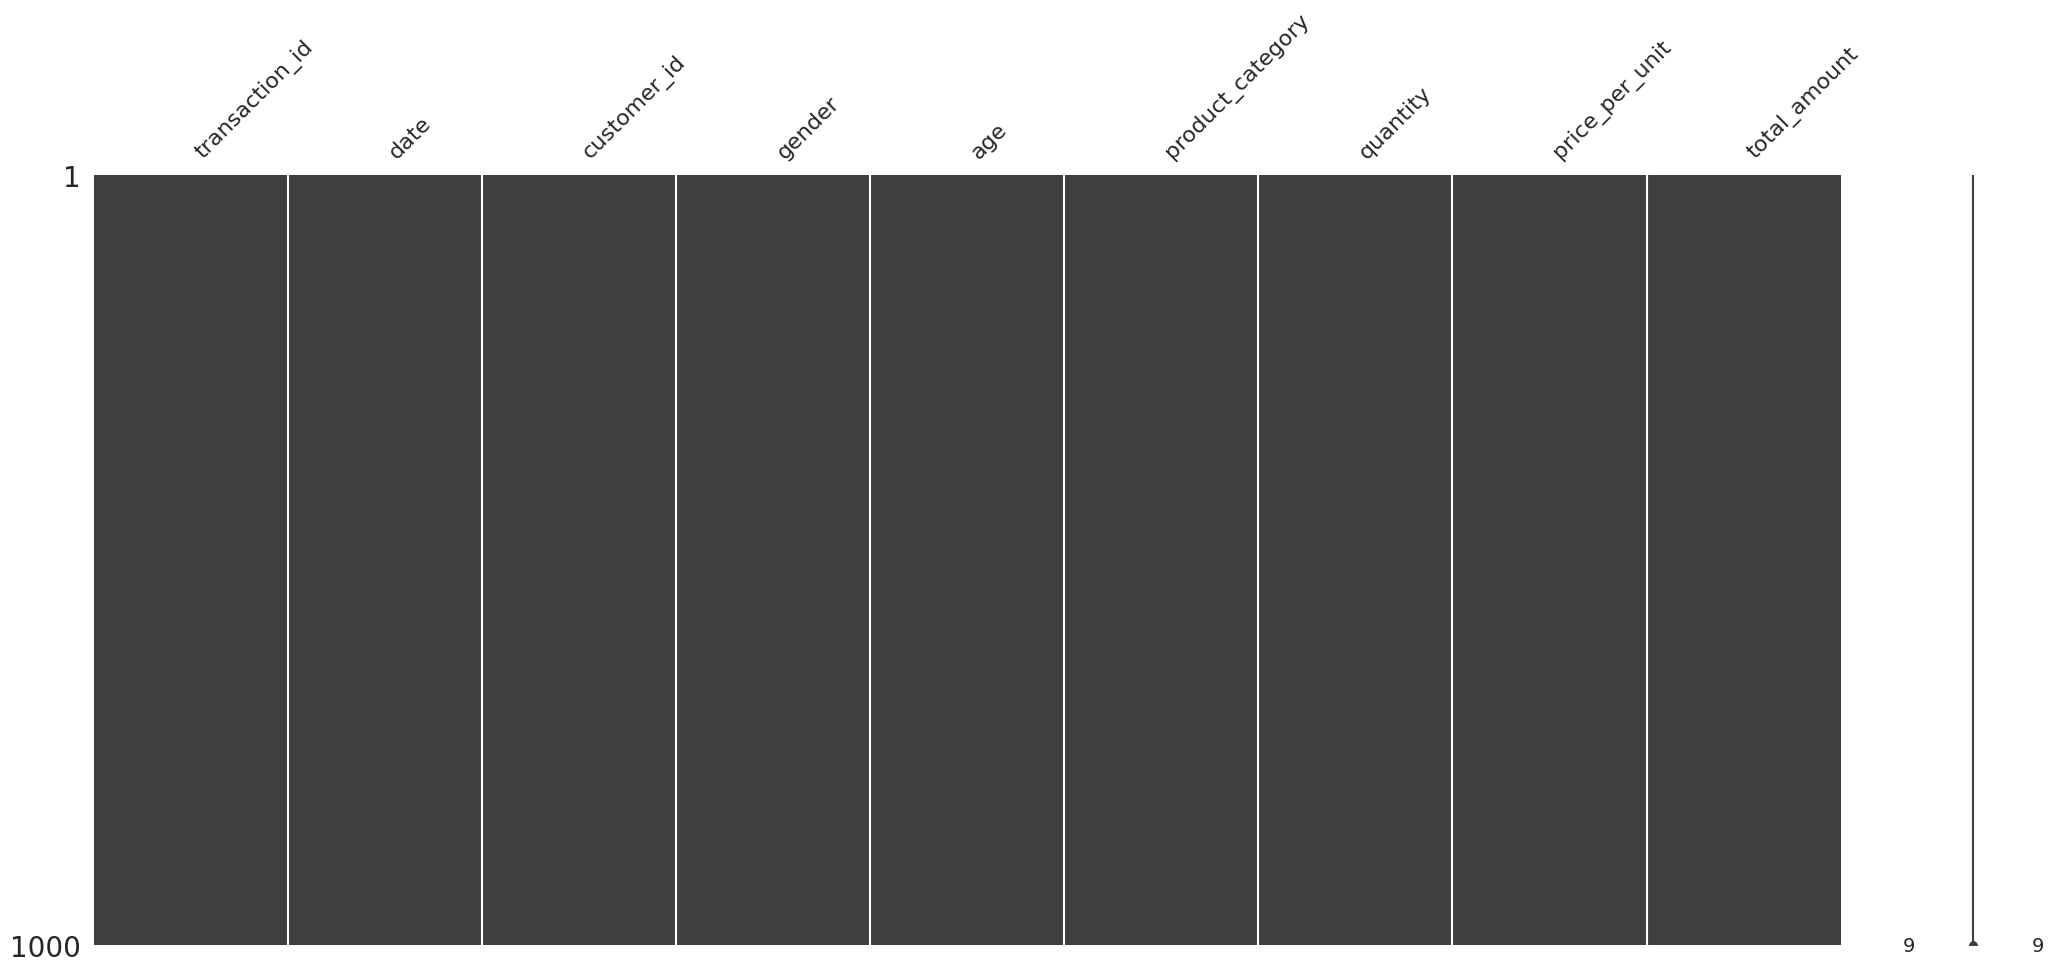

In [ ]:
msno.matrix(df)

<Axes: >

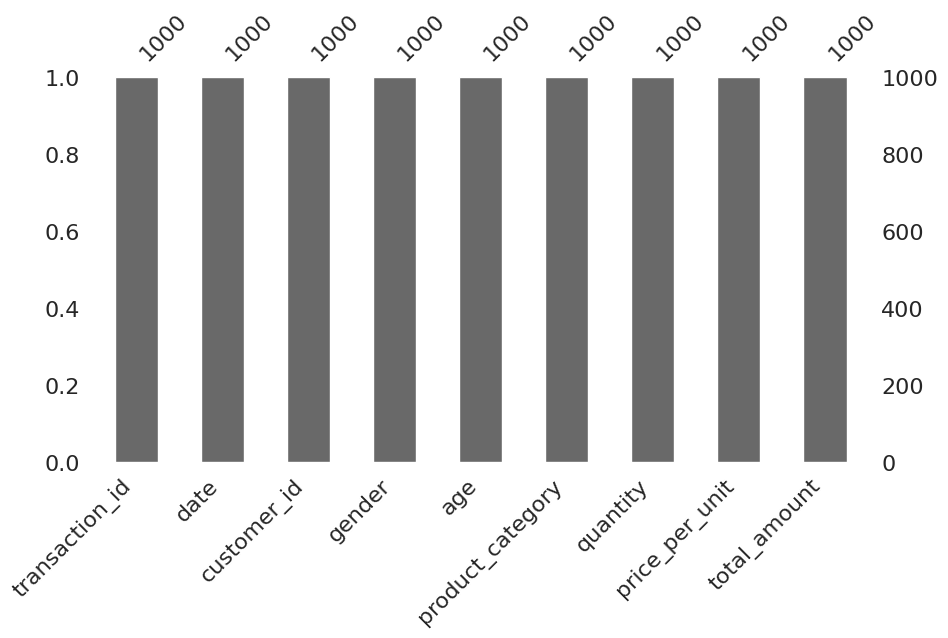

In [ ]:
msno.bar(df, figsize=(10,5))

The above matrix and bar chart further confirm that no missing data can be found in the dataset.

## **2.5. Modifying rows and columns**


### **Drop transaction_id column**

First, we'll remove the transaction_id which is not useful for our analysis.

In [ ]:
df.drop('transaction_id', axis=1, inplace=True)

In [ ]:
df.head()

,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### **Drop 2024 data rows**

As we can see below, the dataset contain 2 rows of data belonging to the year 2024. Since my analysis will only focus on sales trends in 2023, data in 2024 will be excluded.

In [ ]:
df.sort_values(by='date', ascending=False).head()

,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
649,2024-01-01,CUST650,Male,55,Electronics,1,30,30
210,2024-01-01,CUST211,Male,42,Beauty,3,500,1500
856,2023-12-31,CUST857,Male,60,Electronics,2,25,50
907,2023-12-29,CUST908,Male,46,Beauty,4,300,1200
804,2023-12-29,CUST805,Female,30,Beauty,3,500,1500


In [ ]:
# Only keep data belonging to the year 2023
df = df[df['date'].dt.year == 2023]

In [ ]:
df.sort_values(by='date', ascending=False).head()

,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
856,2023-12-31,CUST857,Male,60,Electronics,2,25,50
804,2023-12-29,CUST805,Female,30,Beauty,3,500,1500
232,2023-12-29,CUST233,Female,51,Beauty,2,300,600
519,2023-12-29,CUST520,Female,49,Electronics,4,25,100
907,2023-12-29,CUST908,Male,46,Beauty,4,300,1200


### **Create month and quarter columns**

We will then create 2 new columns which are month and quarter in order to perform time series analysis later.

In [ ]:
# Create a new column with quarters Q1, Q2, etc.
df['quarter'] = 'Q' + df['date'].dt.quarter.astype(str)

# Create a new column with quarters Q1, Q2, etc.
df['month'] = df['date'].dt.to_period('M')
df.head()

,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,quarter,month
0,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Q4,2023-11
1,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Q1,2023-02
2,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Q1,2023-01
3,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Q2,2023-05
4,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Q2,2023-05


### **Create a new age group column**

We will now create a new column named `age_group` to categorize age into different age groups, which will be used for customer behavior analysis.

In [ ]:
df['age'].describe()

,age
count,998.000000
mean,41.377756
std,13.688342
min,18.000000
25%,29.000000
50%,42.000000
75%,53.000000
max,64.000000


From the table, we can tell `age` in this dataset ranges from 18 to 64. Therefore, we will create 4 age groups: Young Adult, Adult, Middle Age and Older Adult.

In [ ]:
age_bins = [18, 24, 44, 54, 64]

age_labels = [
    'Young Adult', # (18-24)
    'Adult', # (25-44)
    'Middle Age', # (45-54)
    'Older Adult', # (55-64)
]

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

In [ ]:
df.head()

,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,quarter,month,age_group
0,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Q4,2023-11,Adult
1,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Q1,2023-02,Adult
2,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Q1,2023-01,Middle Age
3,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Q2,2023-05,Adult
4,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Q2,2023-05,Adult


### **Columns Rearrangements**

In [ ]:
df.columns

Index(['date', 'customer_id', 'gender', 'age', 'product_category', 'quantity',
       'price_per_unit', 'total_amount', 'quarter', 'month', 'age_group'],
      dtype='object')

In [ ]:
# Define a list with sequence of columns
columns = ['date', 'month','quarter','customer_id', 'gender','age', 'age_group',
           'product_category', 'quantity', 'price_per_unit', 'total_amount']

# Assign the new column order to the DataFrame
df = df[columns]
df.head()

,date,month,quarter,customer_id,gender,age,age_group,product_category,quantity,price_per_unit,total_amount
0,2023-11-24,2023-11,Q4,CUST001,Male,34,Adult,Beauty,3,50,150
1,2023-02-27,2023-02,Q1,CUST002,Female,26,Adult,Clothing,2,500,1000
2,2023-01-13,2023-01,Q1,CUST003,Male,50,Middle Age,Electronics,1,30,30
3,2023-05-21,2023-05,Q2,CUST004,Male,37,Adult,Clothing,1,500,500
4,2023-05-06,2023-05,Q2,CUST005,Male,30,Adult,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              998 non-null    datetime64[ns]
 1   month             998 non-null    period[M]     
 2   quarter           998 non-null    object        
 3   customer_id       998 non-null    object        
 4   gender            998 non-null    object        
 5   age               998 non-null    int64         
 6   age_group         977 non-null    category      
 7   product_category  998 non-null    object        
 8   quantity          998 non-null    int64         
 9   price_per_unit    998 non-null    int64         
 10  total_amount      998 non-null    int64         
dtypes: category(1), datetime64[ns](1), int64(4), object(4), period[M](1)
memory usage: 86.9+ KB


# **3. Exploratory Data Analysis and Visualization**
## **Main Question: How do customer demographics, product categories, and seasonal trends influence sales?**

## **3.1. Overall Distribution**

### **Distribution of Numerical Variables**
We will first look at distribution of `age`, `quantity`, `price_per_unit` and `total_amount`.

In [ ]:
df.describe().round(2)

,date,age,quantity,price_per_unit,total_amount
count,998,998.00,998.00,998.00,998.00
mean,2023-07-02 15:40:45.691382784,41.38,2.52,179.72,455.38
min,2023-01-01 00:00:00,18.00,1.00,25.00,25.00
25%,2023-04-08 00:00:00,29.00,1.00,30.00,60.00
50%,2023-06-29 00:00:00,42.00,3.00,50.00,135.00
75%,2023-10-04 00:00:00,53.00,4.00,300.00,900.00
max,2023-12-31 00:00:00,64.00,4.00,500.00,2000.00
std,NaN,13.69,1.13,189.54,559.42


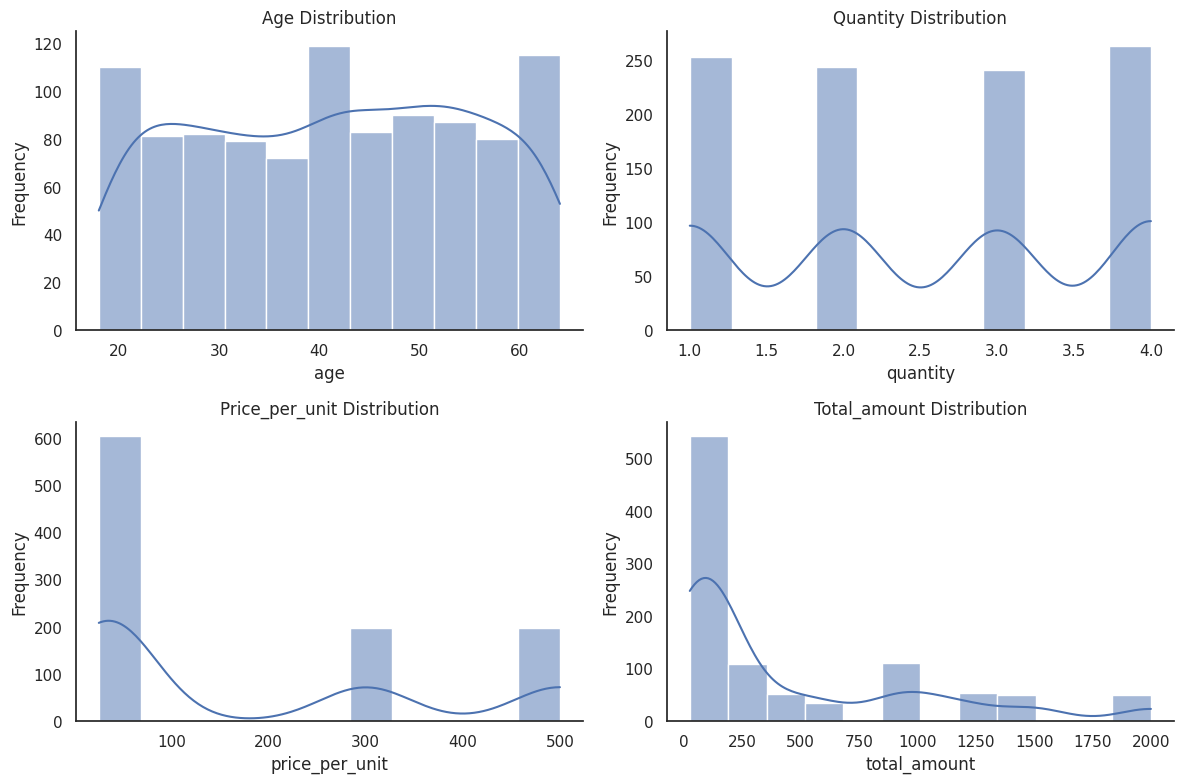

In [ ]:
from numpy._core.defchararray import capitalize
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

numerical_cols = df.select_dtypes(include='number').columns

# Create different histograms for numerical variables
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'{capitalize(col)} Distribution')
    ax.set_ylabel('Frequency')

plt.tight_layout()
sns.despine()
plt.show()

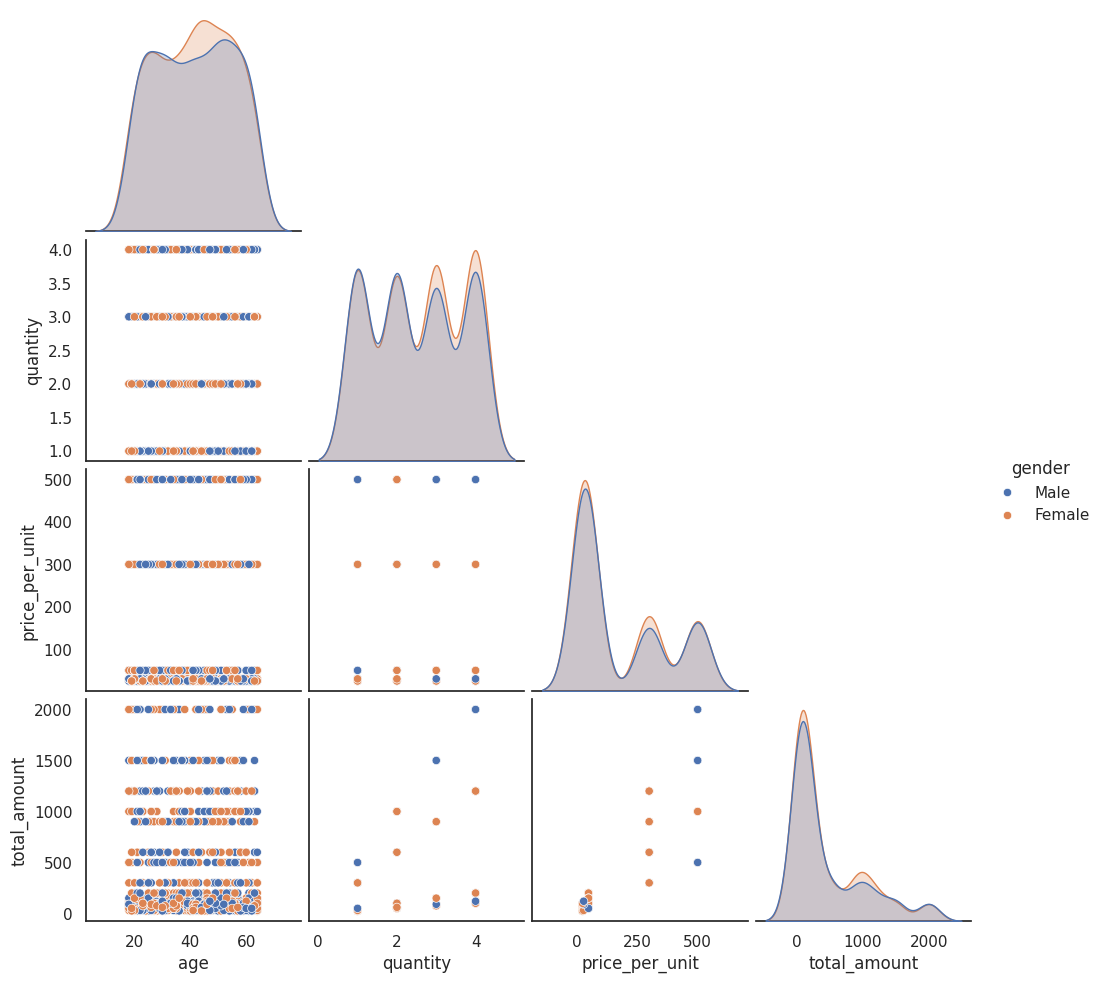

In [ ]:
# Relationships between numeric variables
sns.pairplot(df, hue='gender', corner=True)

plt.show()

### **Distribution of Categorical Variables**
Now let's look at the distribution of categorical features: `gender`, `age_group` and `product_category`.

In [ ]:
# Gender distribution
gender_counts = df['gender'].value_counts()
gender_counts

,count
gender,
Female,510
Male,488


In [ ]:
# Age group distribution
age_group_counts = df['age_group'].value_counts()
age_group_counts

,count
age_group,
Adult,409
Middle Age,225
Older Adult,215
Young Adult,128


In [ ]:
# Product category distribution
product_category_counts = df['product_category'].value_counts()
product_category_counts

,count
product_category,
Clothing,351
Electronics,341
Beauty,306


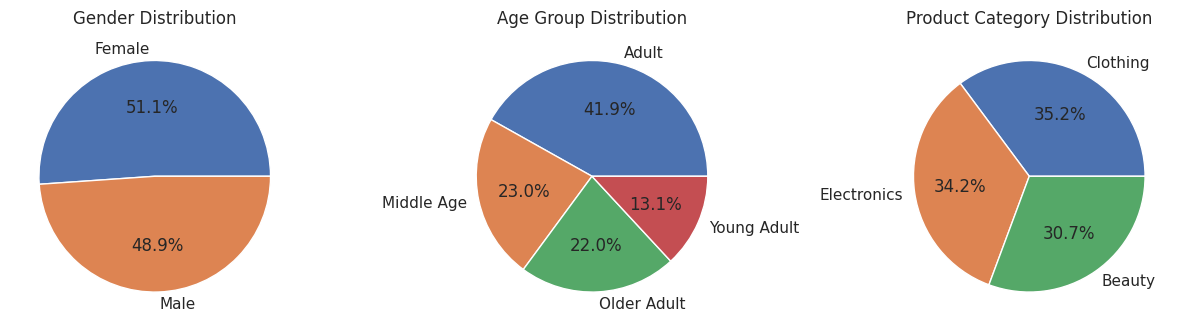

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12,5))

# Pie chart for gender
axs[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
axs[0].set_title('Gender Distribution')

# Pie chart for age_group
axs[1].pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%')
axs[1].set_title('Age Group Distribution')

# # Pie chart for product_category
axs[2].pie(product_category_counts, labels=product_category_counts.index, autopct='%1.1f%%')
axs[2].set_title('Product Category Distribution')

plt.tight_layout()
plt.show()

**Insights:**
- `gender` is fairly distributed between females (51.1%) and males (48.9%).
- `age_group`: Adults make up for almost half of all age groups with 41.9%, while young adult group is the least presented with only 13.1%.
- `product_category`: Clothing is the most frequently purchased category with 35.2%, followed closely by electronics (34.2%). Beauty is the least purchased one with 30.7%.

## **3.2. Customer behavior**


### **Which customer segments (age, gender) spend the most?**
Based on the dataset analysis, age and gender play an important role in shaping customer purchasing behavior in terms of their spending and preferences.

In [ ]:
# Total revenue by gender
revenue_by_gender = df.groupby('gender')['total_amount'].sum().reset_index()
revenue_by_gender

,gender,total_amount
0,Female,232840
1,Male,221630


In [ ]:
# Total revenue by age group
revenue_by_age = df.groupby('age_group')['total_amount'].sum().sort_values(ascending=False).reset_index()
revenue_by_age

,age_group,total_amount
0,Adult,192425
1,Middle Age,97235
2,Older Adult,90160
3,Young Adult,63435


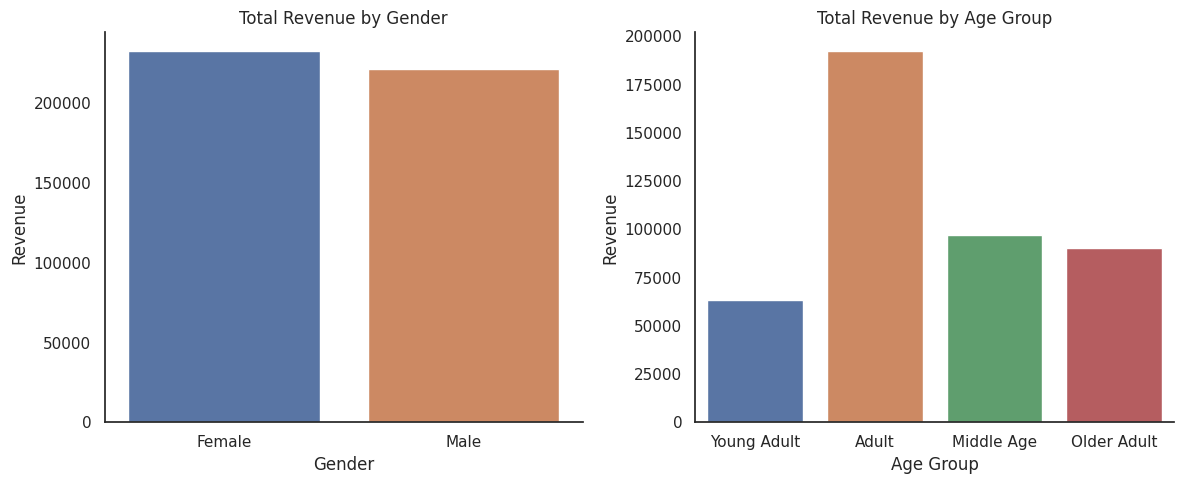

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Bar chart for total revenue by gender
sns.barplot(data=revenue_by_gender, x='gender', y='total_amount', hue='gender', ax=ax1)
ax1.set_title('Total Revenue by Gender')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Revenue')

# Bar chart for total revenue by age group
sns.barplot(data=revenue_by_age, x='age_group', y='total_amount', hue='age_group', ax=ax2)
ax2.set_title('Total Revenue by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Revenue')

plt.tight_layout()
sns.despine()
plt.show()

**Insights:**
- Female customers spend more overall.
- Adults generate the highest revenue, contributing twice as much as the second segment (middle aged customers), and then followed by older aldults. Young Adult customers spend the least, only half as much as older aldults.

Let's break it down further.

In [ ]:
# Total revenue by age and gender
revenue_age_gender = df.groupby(['age_group', 'gender'])['total_amount'].sum().sort_values(ascending=False).reset_index()
revenue_age_gender

,age_group,gender,total_amount
0,Adult,Female,104815
1,Adult,Male,87610
2,Middle Age,Male,50410
3,Middle Age,Female,46825
4,Older Adult,Female,45280
5,Older Adult,Male,44880
6,Young Adult,Male,35455
7,Young Adult,Female,27980


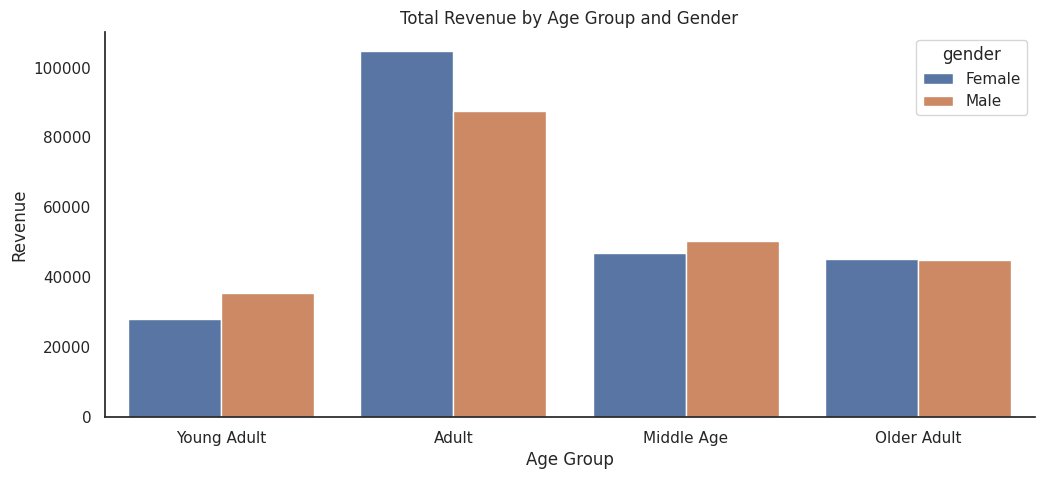

In [ ]:
# Bar chart for total revenue by age and gender
plt.figure(figsize=(12,5))
sns.barplot(data=revenue_age_gender, x='age_group', y='total_amount', hue='gender')
plt.title('Total Revenue by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Revenue')

sns.despine()
plt.show()

**Insights:**
- The adult group contributes the most to total revenues, with females generating about 105,000 and males generating about 88,000. In contrast, the young adults spend the least compared to other groups.
- Among adults and older adults, females spend more than their male counterparts, whereas within the young adults and midle aged group, males outspend their female counterparts.

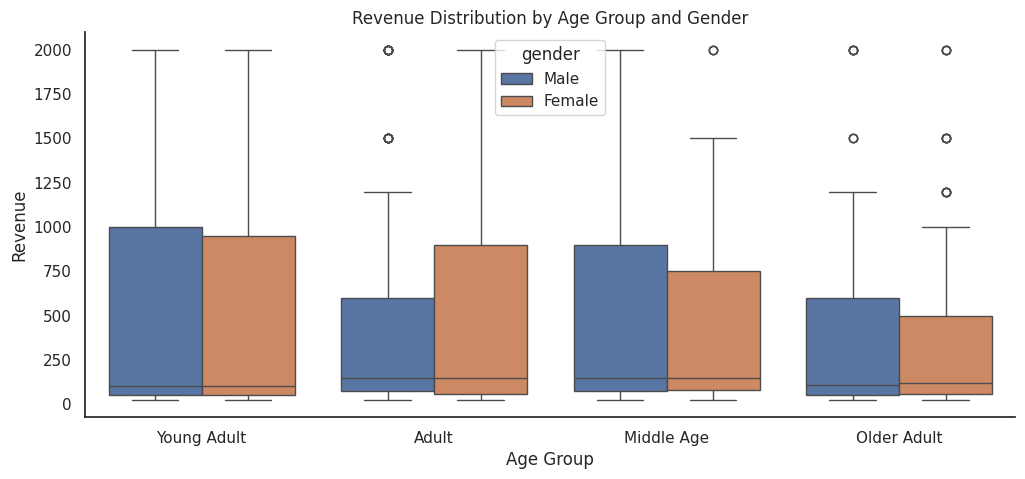

In [ ]:
# Sales per transaction by age and gender
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='age_group', y='total_amount', hue='gender')
plt.title('Revenue Distribution by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Revenue')

sns.despine()
plt.show()

**Insights:** We can see total revenue distribution across different age groups and gender.
- The young adults, female adults and male middle-aged group have higher variation in revenue contribution, while the least variation could be seen in female older adults.
- The overall median revenue for adults and middle aged group is the highest.
- On average, revenues contributed by young adults are the highest.
- Outliers can be seen in male adults, middle aged females, and older adults.

## **3.3. Product Categories**

### **Which product categories generate the highest revenue?**

In [ ]:
# Revenue and quantity sold by category
category_revenue_qty = df.groupby('product_category')[['total_amount', 'quantity']].sum().reset_index()
category_revenue_qty

,product_category,total_amount,quantity
0,Beauty,142015,768
1,Clothing,155580,894
2,Electronics,156875,848


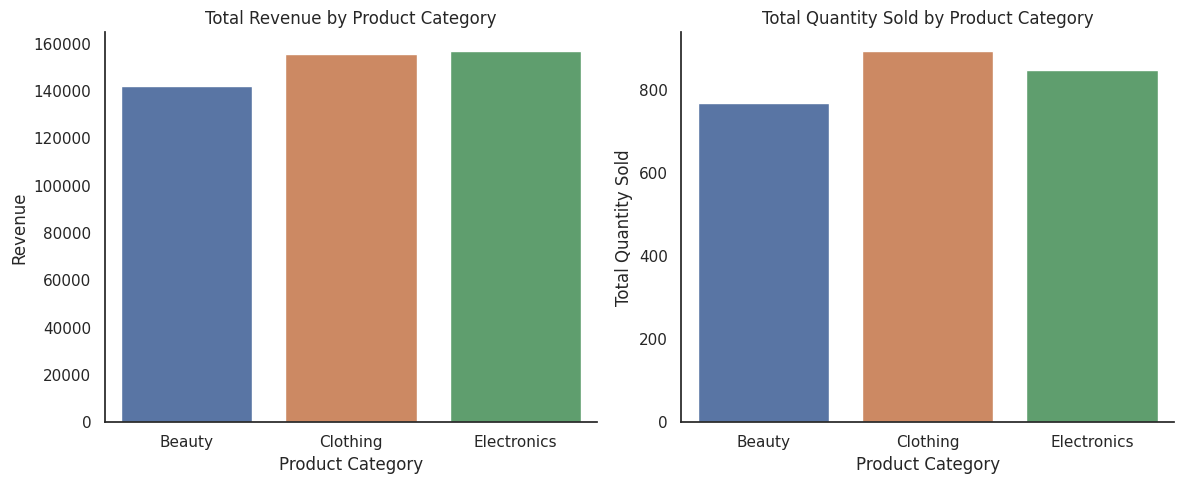

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Bar chart for total revenue by product category
sns.barplot(data=category_revenue_qty, x='product_category', y='total_amount', hue='product_category', ax=ax1)
ax1.set_title('Total Revenue by Product Category')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Revenue')

# Bar chart for quantity sold by product category
sns.barplot(data=category_revenue_qty, x='product_category', y='quantity', hue='product_category', ax=ax2)
ax2.set_title('Total Quantity Sold by Product Category')
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Total Quantity Sold')

plt.tight_layout()
sns.despine()
plt.show()

**Insights:** While clothing is the best-selling category in terms of quantity sold, electronics generates the highest revenue, followed by clothing. In contrast, beauty is the least sold category in terms of both quantity and revenue.

### **Which product categories hold the highest appeal among customers? (In terms of purchasing frequency)**

As we've discussed, Clothing is the most frequently purchased category, followed closely by electronics, whereas beauty is the least purchased one.
We will now drill down further by gender and age groups.


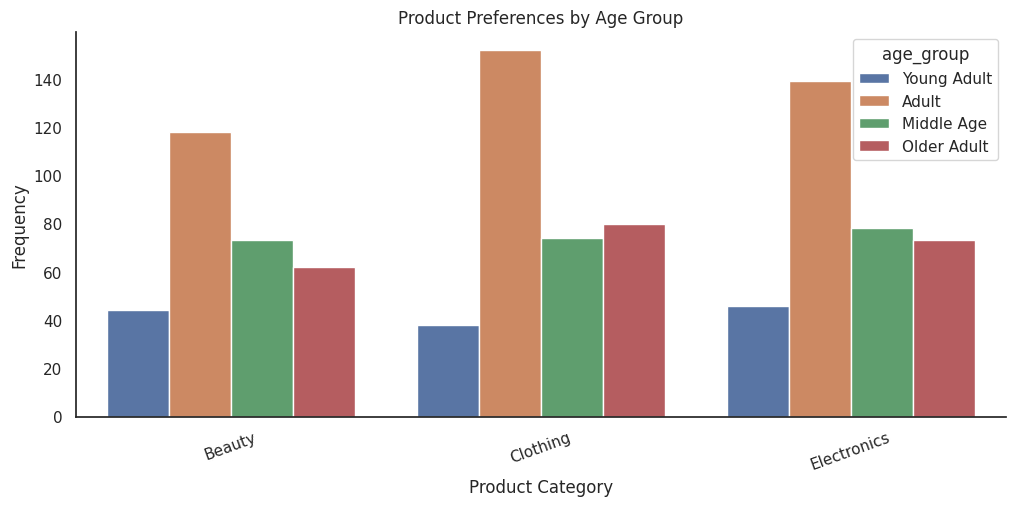

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='product_category', hue='age_group')
plt.title('Product Preferences by Age Group')
plt.xlabel('Product Category')
plt.ylabel('Frequency')
plt.xticks(rotation=20)

sns.despine()
plt.show()

**Insights:**
- Clothing is the most popular category overall across age groups.
- Electronics attract strong interest, especially among adults.
- Beauty products appeal most to Adults and middle aged customers.

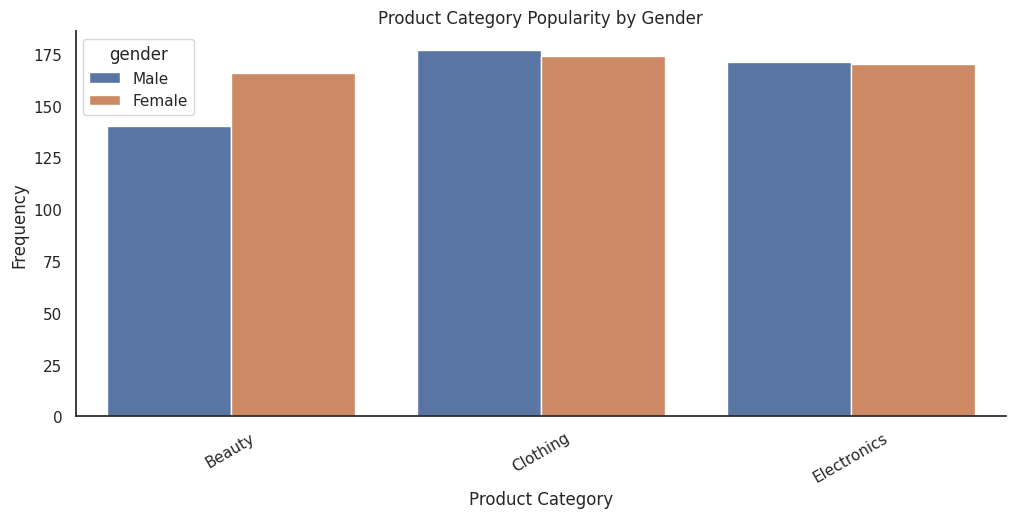

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='product_category', hue='gender')
plt.title("Product Category Popularity by Gender")
plt.xlabel("Product Category")
plt.ylabel("Frequency")
plt.xticks(rotation=30)

sns.despine()
plt.show()

**Insights:**
- Both genders show similar preferences overall.
- Clothing remains the most popular category for both genders (similar pattern to age groups).
- Females prefer beauty more than males, while males slightly favor clothing and electronics.

## **3.4. Price and Quantity**
### **How do price per unit and quantity purchased affect total sales?**

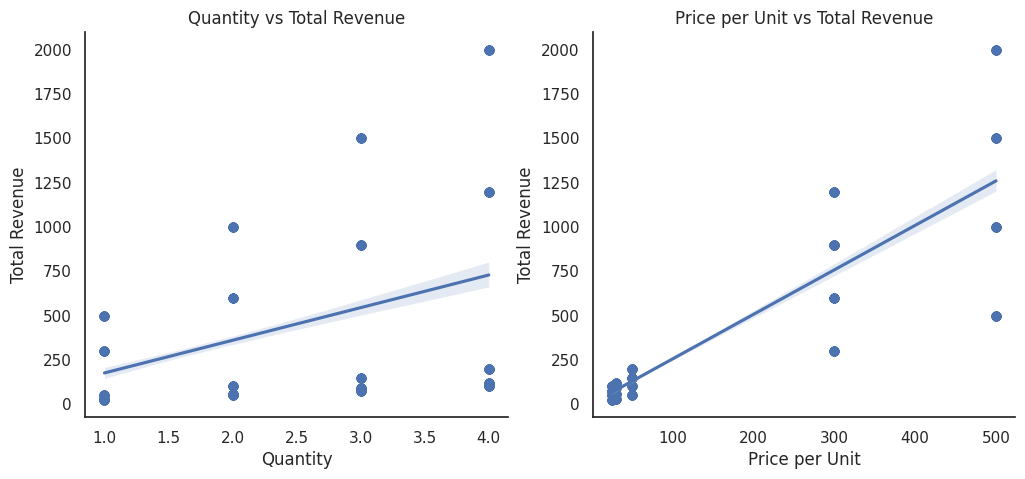

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Scatter plot for quantity vs total revenue
sns.regplot(data=df, x='quantity', y='total_amount', ax=ax[0])
ax[0].set_title('Quantity vs Total Revenue')
ax[0].set_xlabel('Quantity')
ax[0].set_ylabel('Total Revenue')

# Scatter plot for price per unit vs total revenue
sns.regplot(data=df, x='price_per_unit', y='total_amount', ax=ax[1])
ax[1].set_title('Price per Unit vs Total Revenue')
ax[1].set_xlabel('Price per Unit')
ax[1].set_ylabel('Total Revenue')

sns.despine()
plt.show()

**Insight:**
- Quantity and Price per unit both have positive relationships with total revenue, though price per unit shows a stronger relationship compared to quantity. In other words, As quantity/price per unit increases, total revenues also increase.
- There is a lot of variation in the two scatter plots.

## **3.5. Time Series Analysis**
### **How do sales vary across months and quarters?**

Let's look at total monthly sales.

In [ ]:
# Total monthly sales
monthly_sales = df.groupby('month')['total_amount'].sum()

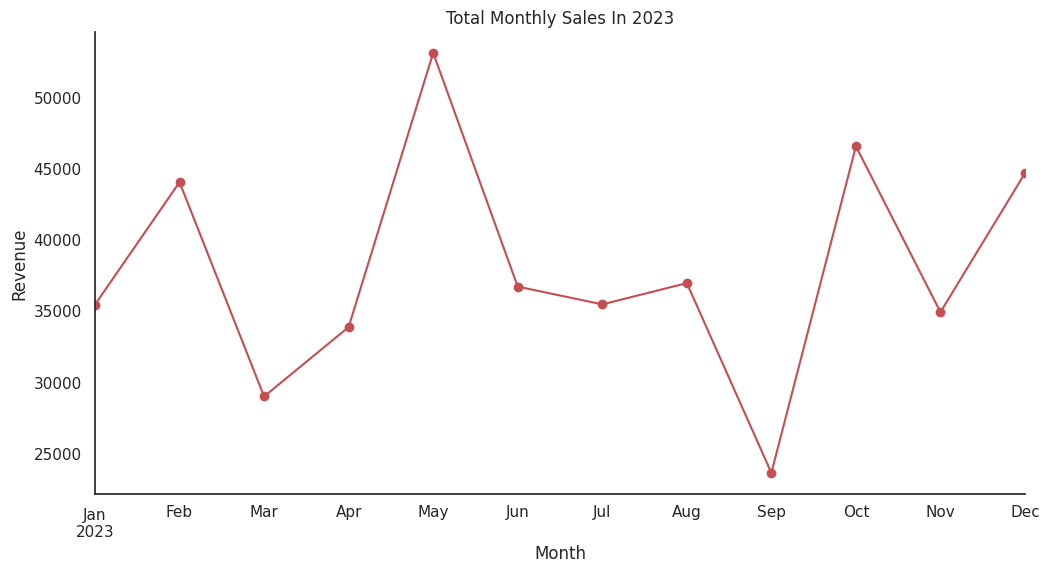

In [ ]:
# Line plot for total monthly sales
monthly_sales.plot(y='total_amount', figsize=(12,6), color='r', marker='o')
plt.title('Total Monthly Sales In 2023')
plt.xlabel('Month')
plt.ylabel('Revenue')

sns.despine()
plt.show()

**Insights:**
- May is the strongest sales month, reaching its peak at about 53,000.
- Sales drop dramatically in March and September, with September being the lowest point of the year.
Sales then bounce back during the last few months of the year, with October being at about 47,000.
- Overall, sales fluctuate throughout the year with frequent spikes.

Now we will look at sales per quarter.

In [ ]:
quarterly_total = df.groupby('quarter')['total_amount'].sum().reset_index()
quarterly_total

,quarter,total_amount
0,Q1,108500
1,Q2,123735
2,Q3,96045
3,Q4,126190


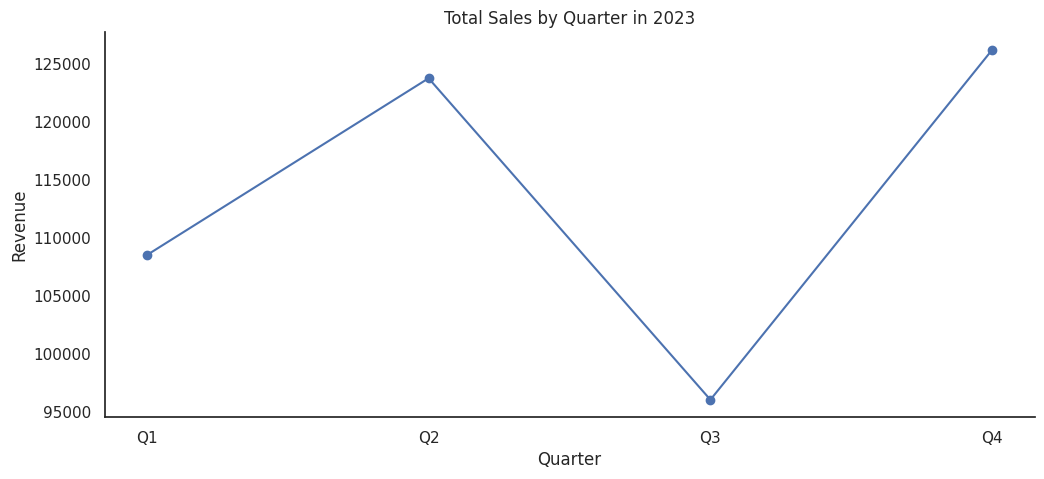

In [ ]:
# Line plot for total sales per quarter
plt.figure(figsize=(12,5))
plt.plot(quarterly_total['quarter'], quarterly_total['total_amount'], marker='o', linestyle='-')
plt.title('Total Sales by Quarter in 2023')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

sns.despine()
plt.show()

**Insights:**
- The second and fourth quarters are the strongest performing quarters, peaking at 124,000 and 126,000 respectively.
- Quarter 3 is the weakest performing of the year, experiencing a major drop to 96,000.


We will also look at average sales generated per quarter.

In [ ]:
# Average sales per quarter
avg_quarterly_sales = df.groupby('quarter')['total_amount'].mean().reset_index()
avg_quarterly_sales

,quarter,total_amount
0,Q1,463.675214
1,Q2,461.697761
2,Q3,415.779221
3,Q4,476.188679


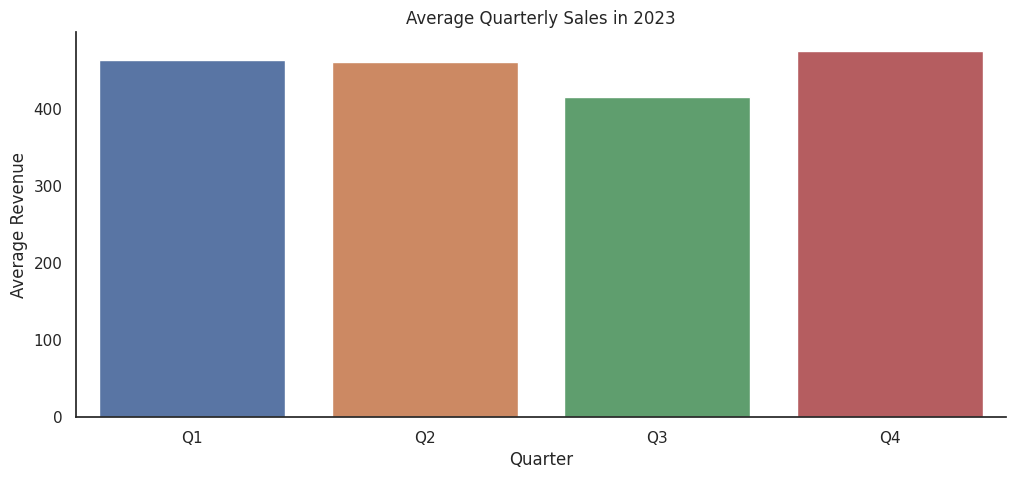

In [ ]:
# Bar chart for average sales per quarter
plt.figure(figsize=(12,5))
sns.barplot(x='quarter', y='total_amount', data=avg_quarterly_sales, hue='quarter')
plt.title('Average Quarterly Sales in 2023')
plt.xlabel('Quarter')
plt.ylabel('Average Revenue')

sns.despine()
plt.show()

**Insights:**
- Average quarterly sales show a similar pattern to the total quarterly sales: highest revenue in quarter 4 and lowest in quarter 3.

# **4. Conclusion**

## **4.1. Summary of key insights**
**1. Customer demographics have a strong influence on the spending behaviors.**
- With balance distribution of gender, females tend to spend more than their male counterparts, especially in adult and older adult groups.
- Adults are the dominant age group in the dataset, generating the highest revenue. In contrast, young adults are the least presented group, thus contributing the least revenue.
- Despite that, young adults generate the highest average sales per transaction.

**2. Product Categories show different patterns between popularity and revenue.**
- Clothing is the most sold category by quantity, followed by electronics. However, electronics generates the highest revenue.
- Beauty performs the weakest in both quantity sold and revenue.
- Overall, females prefer beauty while males slight lean towards clothing and electrics.

**3. Price and Quantity have a strong positive relationship with revenue.**
- As price and quantity increase, total sales also increase.

**4. Seasonal trends strongly influence total sales.**
- Sales peaks in May and drops to the lowest in March and September.
- Quarter 2 and quarter 4 perform the best out of 4 quarters, with quarter 4 reaching yearly high.
- Quarter 3 experiences the major drop, driven by the remarkable September decline.
- Average quarterly sales show similar patterns to total quarterly sales.

## **4.2. Key takeaways**
**1. Target the high-value customers.**

From the analysis, adults make up a large share of the all age groups and contribute the most to revenue. They should be prioritized in marketing campaigns (such as loyalty programs), especially female adults who tend to spend more.

**2. Focus on electronics stocking and pricing management.**

Electronics drive the most revenue, thus focusing on it would help boost more profits.

**3. Seasonal trends suggest promotional strategies.**

According to the seasonal trends uncovered, high sales in May and holiday-adjacent months suggests more inventory, staffing and promotions to maximize revenue, while the low sales in quarter 3 suggests potential for campaigns (for example: launch an "End of Summer" clearance or a "Back to Business" campaign) to counteract the revenue dip and build momentum for the October peak.


**4. Product category preferences and demand vary across demographics.**

The analysis insights suggest demographic tailored marketing. For example, clothing is a universal category, appealing to both genders and different age groups, or beauty products are favored more by females. Therefore, marketing for new gadgets should target male demographics, while skincare campaigns should prioritize female audiences.

In [ ]:
!jupyter nbconvert --to html /content/Python_Data_Analysis_and_Visualization_Hue_Nguyen.ipynb

[NbConvertApp] Converting notebook /content/Python_Data_Analysis_and_Visualization_Hue_Nguyen.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 1582979 bytes to /content/Python_Data_Analysis_and_Visualization_Hue_Nguyen.html
